In [6]:
from koinapy import Koina
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import time
import sys
from pathlib import Path
from functools import reduce
from tqdm import tqdm
import os

project_root = Path.cwd().parent

sys.path.append(str(project_root))

from make_predictions.intensity_predictions import (
    obtain_predictions_pairs,
    safe_obtain_predictions,
    safe_obtain_ccs_predictions,
    safe_obtain_rt_predictions,
)
from seq_utils.fasta_to_peptides import create_tryptic_peptides
from seq_utils.peptide import (
    remove_non_il,
    remove_ux_containing,
    switch_first_il,
    switch_random_il,
)
from metrics.get_metrics import metrics_comparison

In [7]:
# Randomly sample 2000 peptides (and corresponding switched peptides) reproducibly
sample_peps = True
sample_size = 20000

# Specify the path to your FASTA file
fasta_file = "../fasta/UP000005640_9606.fasta"

# Generate tryptic peptides
peptides = create_tryptic_peptides(fasta_file)

# Remove non-I/L amino acids
peptides = remove_non_il(peptides)
peptides = remove_ux_containing(peptides)
peptides = np.array(peptides)

if sample_peps:
    rng = np.random.default_rng(42)
    n_peptides = len(peptides)
    indices = rng.choice(n_peptides, size=sample_size, replace=False)
    peptides = peptides[indices]

# Create correct, switched pairs
peptides_switched = np.array([switch_random_il(peptide) for peptide in peptides])

In [8]:
peptides_switch_predictions_f = "../temp_data/peptides_switch_predictions.csv"
peptides_predictions_f = "../temp_data/peptides_predictions.csv"

batch_size = 5000
peptides_switch_predictions_list = []
peptides_predictions_list = []


if os.path.exists(peptides_switch_predictions_f) and os.path.exists(
    peptides_predictions_f
) and False:
    peptides_switch_predictions = pd.read_csv(peptides_switch_predictions_f)
    peptides_predictions = pd.read_csv(peptides_predictions_f)
else:
    for i in tqdm(range(0, len(peptides), batch_size)):
        batch_switched = peptides_switched[i : i + batch_size]
        batch = peptides[i : i + batch_size]

        print(batch_switched)

        peptides_switch_predictions_list.append(
            safe_obtain_predictions(batch_switched, switched=False)
        )
        peptides_predictions_list.append(safe_obtain_predictions(batch, switched=True))

    peptides_switch_predictions = pd.concat(
        peptides_switch_predictions_list, ignore_index=True
    )
    peptides_predictions = pd.concat(peptides_predictions_list, ignore_index=True)

    peptides_switch_predictions.to_csv(
        peptides_switch_predictions_f,
        index=False,
    )
    peptides_predictions.to_csv(peptides_predictions_f, index=False)

  0%|          | 0/4 [00:00<?, ?it/s]

['LGQSPAQDTPVLGPCWDPMAIGTQGR' 'ATNTANNSVPFVSSPPMFVIDK' 'IIAWAPVEPSFSAR'
 ... 'AHCEEIEGQK' 'DLDMIFPGGAGR' 'SDSAFWITR']
               peptide_sequences  precursor_charges  collision_energies  \
0     LGQSPAQDTPVLGPCWDPMAIGTQGR                  2                  28   
1         ATNTANNSVPFVSSPPMFVIDK                  2                  28   
2                 IIAWAPVEPSFSAR                  2                  28   
3                        QGHGVIR                  2                  28   
4                       LIFSDGEK                  2                  28   
...                          ...                ...                 ...   
4995                   IGMGFGNCR                  2                  28   
4996      AQPQEEGPTDIPCPPDPASDTK                  2                  28   
4997                  AHCEEIEGQK                  2                  28   
4998                DLDMIFPGGAGR                  2                  28   
4999                   SDSAFWITR                  2      

Prosit_2020_intensity_HCD::   0%|          | 0/5 [00:00<?, ?it/s]

               peptide_sequences  precursor_charges  collision_energies  \
0     LGQSPAQDTPVLGPCWDPMALGTQGR                  2                  28   
1         ATNTANNSVPFVSSPPMFVLDK                  2                  28   
2                 ILAWAPVEPSFSAR                  2                  28   
3                        QGHGVLR                  2                  28   
4                       LLFSDGEK                  2                  28   
...                          ...                ...                 ...   
4995                   LGMGFGNCR                  2                  28   
4996      AQPQEEGPTDLPCPPDPASDTK                  2                  28   
4997                  AHCEELEGQK                  2                  28   
4998                DLDMLFPGGAGR                  2                  28   
4999                   SDSAFWLTR                  2                  28   

     instrument_types fragmentation_types  
0               LUMOS                 HCD  
1          

Prosit_2020_intensity_HCD::   0%|          | 0/5 [00:00<?, ?it/s]

...

['EFNEDGALAVIQQFK' 'EGSFELVEK' 'GSIPANVPTPR' ... 'VPHVAIQK' 'LVGGSAAGR'
 'TEVCSPIR']
        peptide_sequences  precursor_charges  collision_energies  \
0         EFNEDGALAVIQQFK                  2                  28   
1               EGSFELVEK                  2                  28   
2             GSIPANVPTPR                  2                  28   
3     TDDITSGYMTDGGIGLYTR                  2                  28   
4      HGEFWLEFNSGSIFCVTK                  2                  28   
...                   ...                ...                 ...   
4995       VLDANSCQSEIHEK                  2                  28   
4996        KPSLLAHPGPIVK                  2                  28   
4997             VPHVAIQK                  2                  28   
4998            LVGGSAAGR                  2                  28   
4999             TEVCSPIR                  2                  28   

     instrument_types fragmentation_types  
0               LUMOS                 HCD  
1         

Prosit_2020_intensity_HCD::   0%|          | 0/5 [00:00<?, ?it/s]

        peptide_sequences  precursor_charges  collision_energies  \
0         EFNEDGALAVLQQFK                  2                  28   
1               EGSFEIVEK                  2                  28   
2             GSLPANVPTPR                  2                  28   
3     TDDITSGYMTDGGLGLYTR                  2                  28   
4      HGEFWLEFNSGSLFCVTK                  2                  28   
...                   ...                ...                 ...   
4995       VLDANSCQSELHEK                  2                  28   
4996        KPSLLAHPGPLVK                  2                  28   
4997             VPHVALQK                  2                  28   
4998            IVGGSAAGR                  2                  28   
4999             TEVCSPLR                  2                  28   

     instrument_types fragmentation_types  
0               LUMOS                 HCD  
1               LUMOS                 HCD  
2               LUMOS                 HCD  
3      

Prosit_2020_intensity_HCD::   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:10<00:00,  2.65s/it]



In [9]:
peptides_switch_predictions_f_ccs = "../temp_data/peptides_switch_predictions_ccs.csv"
peptides_predictions_f_ccs = "../temp_data/peptides_predictions_ccs.csv"

batch_size = 5000
peptides_switch_predictions_list_ccs = []
peptides_predictions_list_ccs = []


if (
    os.path.exists(peptides_switch_predictions_f_ccs)
    and os.path.exists(peptides_predictions_f_ccs)
    and False
):
    peptides_switch_predictions_ccs = pd.read_csv(peptides_switch_predictions_f_ccs)
    peptides_predictions_ccs = pd.read_csv(peptides_predictions_f_ccs)
else:
    for i in tqdm(range(0, len(peptides), batch_size)):
        batch_switched = peptides_switched[i : i + batch_size]
        batch = peptides[i : i + batch_size]

        print(batch_switched)

        peptides_switch_predictions_list_ccs.append(
            safe_obtain_ccs_predictions(batch_switched, switched=False)
        )
        peptides_predictions_list_ccs.append(
            safe_obtain_ccs_predictions(batch, switched=True)
        )

    peptides_switch_predictions_ccs = pd.concat(
        peptides_switch_predictions_list_ccs, ignore_index=True
    )
    peptides_predictions_ccs = pd.concat(peptides_predictions_list_ccs, ignore_index=True)

    peptides_switch_predictions_ccs.to_csv(
        peptides_switch_predictions_f_ccs,
        index=False,
    )
    peptides_predictions_ccs.to_csv(peptides_predictions_f_ccs, index=False)

  0%|          | 0/4 [00:00<?, ?it/s]

['LGQSPAQDTPVLGPCWDPMAIGTQGR' 'ATNTANNSVPFVSSPPMFVIDK' 'IIAWAPVEPSFSAR'
 ... 'AHCEEIEGQK' 'DLDMIFPGGAGR' 'SDSAFWITR']
CCS prediction input shape: (5000, 2)


AlphaPept_ccs_generic::   0%|          | 0/5 [00:00<?, ?it/s]

CCS prediction input shape: (5000, 2)


AlphaPept_ccs_generic::   0%|          | 0/5 [00:00<?, ?it/s]

...

['EFNEDGALAVIQQFK' 'EGSFELVEK' 'GSIPANVPTPR' ... 'VPHVAIQK' 'LVGGSAAGR'
 'TEVCSPIR']
CCS prediction input shape: (5000, 2)


AlphaPept_ccs_generic::   0%|          | 0/5 [00:00<?, ?it/s]

CCS prediction input shape: (5000, 2)


AlphaPept_ccs_generic::   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:05<00:00,  1.49s/it]



In [10]:
# Map switched sequences back to original peptides (used by all prediction types)
switched_to_orig = dict(zip(peptides_switched, peptides))

# Create unique ID for each peptide sequence + charge combination (CCS predictions)
peptides_predictions_ccs["seq_charge"] = (
    peptides_predictions_ccs["peptide_sequences"]
    + "/"
    + peptides_predictions_ccs["precursor_charges"].astype(str)
)
unique_combinations_ccs = peptides_predictions_ccs["seq_charge"].unique()
seq_charge_to_id_ccs = {combo: i for i, combo in enumerate(unique_combinations_ccs)}

peptides_predictions_ccs["ID"] = peptides_predictions_ccs["seq_charge"].map(seq_charge_to_id_ccs)

# Create the same ID column for switched CCS predictions based on original peptide mapping
peptides_switch_predictions_ccs["seq_charge"] = (
    peptides_switch_predictions_ccs["peptide_sequences"]
    + "/"
    + peptides_switch_predictions_ccs["precursor_charges"].astype(str)
)

# Map switched sequences back to original IDs (switched peptide -> original peptide -> ID)
peptides_switch_predictions_ccs["orig_seq_charge"] = peptides_switch_predictions_ccs.apply(
    lambda row: switched_to_orig.get(row["peptide_sequences"], row["peptide_sequences"])
    + "/"
    + str(row["precursor_charges"]),
    axis=1,
)
peptides_switch_predictions_ccs["ID"] = peptides_switch_predictions_ccs["orig_seq_charge"].map(seq_charge_to_id_ccs)

print(f"Unique peptide+charge combinations (CCS): {len(unique_combinations_ccs)}")
print(f"peptides_predictions_ccs IDs: {peptides_predictions_ccs['ID'].nunique()}")
print(f"peptides_switch_predictions_ccs IDs: {peptides_switch_predictions_ccs['ID'].nunique()}")

Unique peptide+charge combinations (CCS): 20000
peptides_predictions_ccs IDs: 20000
peptides_switch_predictions_ccs IDs: 20000


In [ ]:
peptides_switch_predictions_f_rt = "../temp_data/peptides_switch_predictions_rt.csv"
peptides_predictions_f_rt = "../temp_data/peptides_predictions_rt.csv"

batch_size = 5000
peptides_switch_predictions_list_rt = []
peptides_predictions_list_rt = []

if (
    os.path.exists(peptides_switch_predictions_f_rt)
    and os.path.exists(peptides_predictions_f_rt)
    and False
):
    peptides_switch_predictions_rt = pd.read_csv(peptides_switch_predictions_f_rt)
    peptides_predictions_rt = pd.read_csv(peptides_predictions_f_rt)
else:
    for i in tqdm(range(0, len(peptides), batch_size)):
        batch_switched = peptides_switched[i : i + batch_size]
        batch = peptides[i : i + batch_size]

        print(batch_switched)

        peptides_switch_predictions_list_rt.append(
            safe_obtain_rt_predictions(batch_switched, switched=False, model="Deeplc_hela_hf")
        )
        peptides_predictions_list_rt.append(
            safe_obtain_rt_predictions(batch, switched=True, model="Deeplc_hela_hf")
        )

    peptides_switch_predictions_rt = pd.concat(
        peptides_switch_predictions_list_rt, ignore_index=True
    )
    peptides_predictions_rt = pd.concat(peptides_predictions_list_rt, ignore_index=True)

    peptides_switch_predictions_rt.to_csv(
        peptides_switch_predictions_f_rt,
        index=False,
    )
    peptides_predictions_rt.to_csv(peptides_predictions_f_rt, index=False)

  0%|          | 0/4 [00:00<?, ?it/s]

['LGQSPAQDTPVLGPCWDPMAIGTQGR' 'ATNTANNSVPFVSSPPMFVIDK' 'IIAWAPVEPSFSAR'
 ... 'AHCEEIEGQK' 'DLDMIFPGGAGR' 'SDSAFWITR']
RT prediction input shape: (5000, 1)


Deeplc_hela_hf::   0%|          | 0/5 [00:00<?, ?it/s]

RT prediction input shape: (5000, 1)


Deeplc_hela_hf::   0%|          | 0/5 [00:00<?, ?it/s]

...

['EFNEDGALAVIQQFK' 'EGSFELVEK' 'GSIPANVPTPR' ... 'VPHVAIQK' 'LVGGSAAGR'
 'TEVCSPIR']
RT prediction input shape: (5000, 1)


Deeplc_hela_hf::   0%|          | 0/5 [00:00<?, ?it/s]

RT prediction input shape: (5000, 1)


Deeplc_hela_hf::   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:05<00:00,  1.41s/it]



In [12]:
peptides_predictions_rt

,peptide_sequences,irt,non_switched
0,LGQSPAQDTPVLGPCWDPMALGTQGR,9.237985,True
1,ATNTANNSVPFVSSPPMFVLDK,8.884091,True
2,ILAWAPVEPSFSAR,8.610691,True
3,QGHGVLR,2.128205,True
4,LLFSDGEK,5.020106,True
...,...,...,...
19995,VLDANSCQSELHEK,3.886431,True
19996,KPSLLAHPGPLVK,4.351929,True
19997,VPHVALQK,2.648277,True
19998,IVGGSAAGR,2.167102,True


In [13]:
# Create unique ID for each peptide sequence (RT predictions - no charge needed)
peptides_predictions_rt["seq"] = peptides_predictions_rt["peptide_sequences"]
unique_sequences_rt = peptides_predictions_rt["seq"].unique()
seq_to_id_rt = {seq: i for i, seq in enumerate(unique_sequences_rt)}

peptides_predictions_rt["ID"] = peptides_predictions_rt["seq"].map(seq_to_id_rt)

# Create the same ID column for switched RT predictions based on original peptide mapping
peptides_switch_predictions_rt["seq"] = peptides_switch_predictions_rt["peptide_sequences"]

# Map switched sequences back to original IDs (switched peptide -> original peptide -> ID)
# Note: switched_to_orig should already be defined from fragment intensity processing
peptides_switch_predictions_rt["orig_seq"] = peptides_switch_predictions_rt["peptide_sequences"].map(
    lambda x: switched_to_orig.get(x, x)
)
peptides_switch_predictions_rt["ID"] = peptides_switch_predictions_rt["orig_seq"].map(seq_to_id_rt)

print(f"Unique peptide sequences (RT): {len(unique_sequences_rt)}")
print(f"peptides_predictions_rt IDs: {peptides_predictions_rt['ID'].nunique()}")
print(f"peptides_switch_predictions_rt IDs: {peptides_switch_predictions_rt['ID'].nunique()}")

Unique peptide sequences (RT): 20000
peptides_predictions_rt IDs: 20000
peptides_switch_predictions_rt IDs: 20000


In [14]:
# Calculate RT error metrics between original and I/L-swapped predictions
peptides_predictions_rt["rt_error"] = (
    peptides_predictions_rt["irt"] - peptides_switch_predictions_rt["irt"]
)
peptides_predictions_rt["rt_abs_error"] = (
    peptides_predictions_rt["irt"] - peptides_switch_predictions_rt["irt"]
).abs()

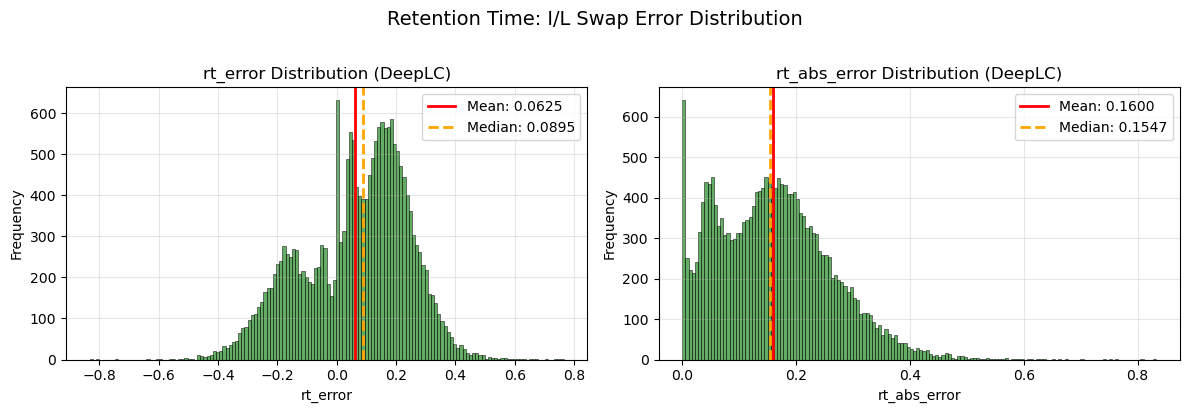

In [ ]:
metrics_to_plot_rt = ["rt_error", "rt_abs_error"]
model_name_rt = "DeepLC"

fig, axes = plt.subplots(1, len(metrics_to_plot_rt), figsize=(12, 4))

for idx, metric in enumerate(metrics_to_plot_rt):
    ax = axes[idx]
    values = peptides_predictions_rt[metric].dropna()

    # Histogram
    ax.hist(
        values, bins=150, alpha=0.7, color="forestgreen", edgecolor="black", linewidth=0.5
    )

    # Add mean and median lines
    mean_val = values.mean()
    median_val = values.median()
    ax.axvline(
        mean_val, color="red", linestyle="-", linewidth=2, label=f"Mean: {mean_val:.4f}"
    )
    ax.axvline(
        median_val,
        color="orange",
        linestyle="--",
        linewidth=2,
        label=f"Median: {median_val:.4f}",
    )

    ax.set_xlabel(f"{metric}")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{metric} Distribution ({model_name_rt})")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

plt.suptitle("Retention Time: I/L Swap Error Distribution", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# Create unique ID for each peptide sequence + charge combination
peptides_predictions["seq_charge"] = (
    peptides_predictions["peptide_sequences"]
    + "/"
    + peptides_predictions["precursor_charges"].astype(str)
)
unique_combinations = peptides_predictions["seq_charge"].unique()
seq_charge_to_id = {combo: i for i, combo in enumerate(unique_combinations)}

peptides_predictions["ID"] = peptides_predictions["seq_charge"].map(seq_charge_to_id)

# Create the same ID column for switched predictions based on original peptide mapping
peptides_switch_predictions["seq_charge"] = (
    peptides_switch_predictions["peptide_sequences"]
    + "/"
    + peptides_switch_predictions["precursor_charges"].astype(str)
)

# Map switched sequences back to original IDs (switched peptide -> original peptide -> ID)
# Note: switched_to_orig is defined earlier in the CCS ID creation cell
peptides_switch_predictions["orig_seq_charge"] = peptides_switch_predictions.apply(
    lambda row: switched_to_orig.get(row["peptide_sequences"], row["peptide_sequences"])
    + "/"
    + str(row["precursor_charges"]),
    axis=1,
)
peptides_switch_predictions["ID"] = peptides_switch_predictions["orig_seq_charge"].map(seq_charge_to_id)

print(f"Unique peptide+charge combinations: {len(unique_combinations)}")
print(f"peptides_predictions IDs: {peptides_predictions['ID'].nunique()}")
print(f"peptides_switch_predictions IDs: {peptides_switch_predictions['ID'].nunique()}")

Unique peptide+charge combinations: 20000
peptides_predictions IDs: 20000
peptides_switch_predictions IDs: 20000


In [17]:
score_df = metrics_comparison(peptides_predictions, peptides_switch_predictions)

In [18]:
peptides_predictions_ccs["error"] = (
    peptides_predictions_ccs["ccs"] - peptides_switch_predictions_ccs["ccs"]
)
peptides_predictions_ccs["abs_error"] = (
    peptides_predictions_ccs["ccs"] - peptides_switch_predictions_ccs["ccs"]
).abs()

In [19]:
metrics_to_plot = ["mse", "dot_product"]
model_name = "Prosit"

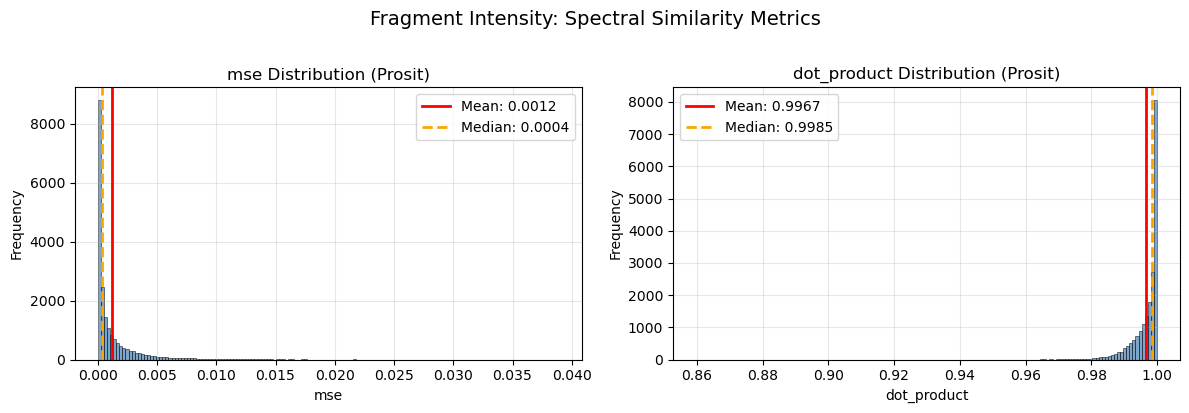

In [ ]:
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(12, 4))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    values = score_df[metric].dropna()

    # Histogram
    ax.hist(values, bins=150, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)

    # Add mean and median lines
    mean_val = values.mean()
    median_val = values.median()
    ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')

    ax.set_xlabel(f"{metric}")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{metric} Distribution ({model_name})")
    if metric == "dot_product":
        ax.legend(loc="upper left")
    else:    
        ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Fragment Intensity: Spectral Similarity Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [21]:
metrics_to_plot = ["error", "abs_error"]
model_name = "AlphaPeptDeep"

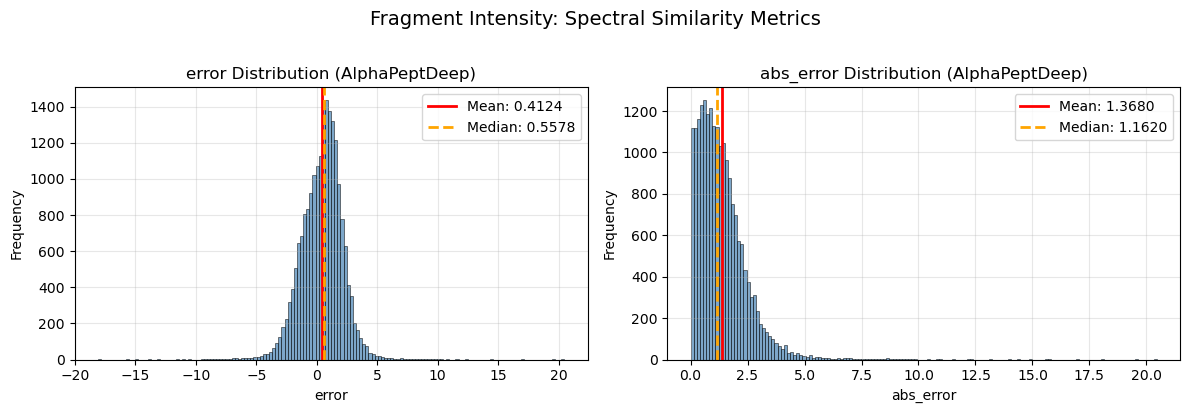

In [ ]:
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(12, 4))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    values = peptides_predictions_ccs [metric].dropna()

    # Histogram
    ax.hist(
        values, bins=150, alpha=0.7, color="steelblue", edgecolor="black", linewidth=0.5
    )

    # Add mean and median lines
    mean_val = values.mean()
    median_val = values.median()
    ax.axvline(
        mean_val, color="red", linestyle="-", linewidth=2, label=f"Mean: {mean_val:.4f}"
    )
    ax.axvline(
        median_val,
        color="orange",
        linestyle="--",
        linewidth=2,
        label=f"Median: {median_val:.4f}",
    )

    ax.set_xlabel(f"{metric}")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{metric} Distribution ({model_name})")
    if metric == "dot_product":
        ax.legend(loc="upper left")
    else:
        ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

plt.suptitle("Fragment Intensity: Spectral Similarity Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

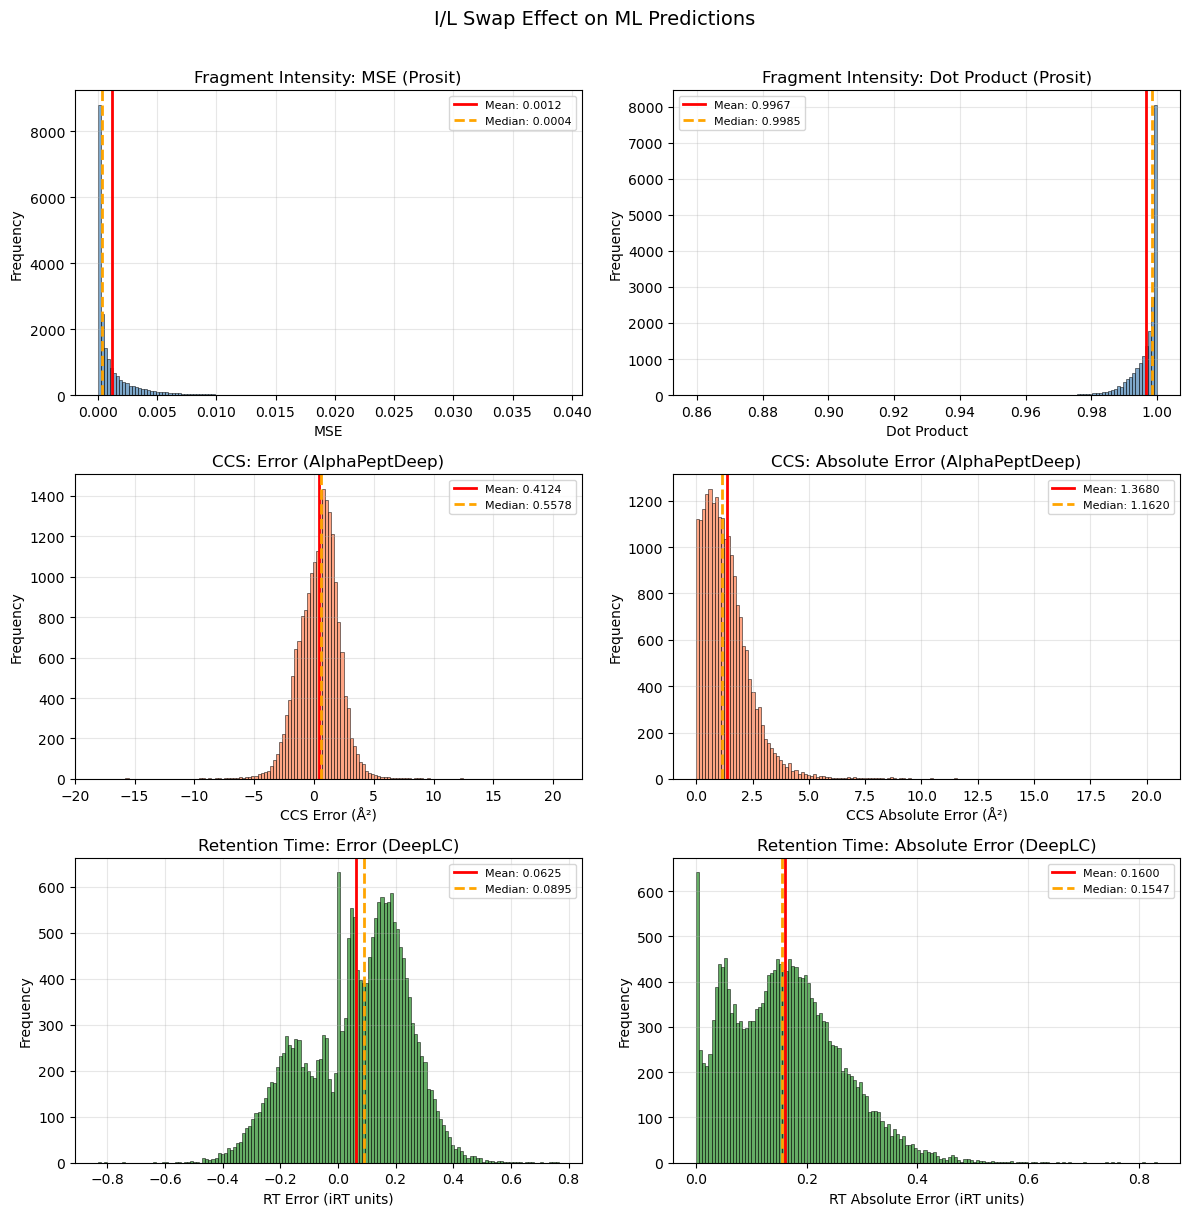

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# Row 1: Fragment Intensity Metrics
# MSE
ax = axes[0, 0]
values = score_df["mse"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("MSE")
ax.set_ylabel("Frequency")
ax.set_title("Fragment Intensity: MSE (Prosit)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Dot Product
ax = axes[0, 1]
values = score_df["dot_product"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("Dot Product")
ax.set_ylabel("Frequency")
ax.set_title("Fragment Intensity: Dot Product (Prosit)")
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# Row 2: CCS Metrics
# CCS Error
ax = axes[1, 0]
values = peptides_predictions_ccs["error"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='coral', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("CCS Error (Å²)")
ax.set_ylabel("Frequency")
ax.set_title("CCS: Error (AlphaPeptDeep)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# CCS Absolute Error
ax = axes[1, 1]
values = peptides_predictions_ccs["abs_error"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='coral', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("CCS Absolute Error (Å²)")
ax.set_ylabel("Frequency")
ax.set_title("CCS: Absolute Error (AlphaPeptDeep)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Row 3: Retention Time Metrics
# RT Error
ax = axes[2, 0]
values = peptides_predictions_rt["rt_error"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='forestgreen', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("RT Error (iRT units)")
ax.set_ylabel("Frequency")
ax.set_title("Retention Time: Error (DeepLC)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# RT Absolute Error
ax = axes[2, 1]
values = peptides_predictions_rt["rt_abs_error"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='forestgreen', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("RT Absolute Error (iRT units)")
ax.set_ylabel("Frequency")
ax.set_title("Retention Time: Absolute Error (DeepLC)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("I/L Swap Effect on ML Predictions", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../temp_data/combined_il_swap_figure.png", dpi=300, bbox_inches='tight')
plt.show()

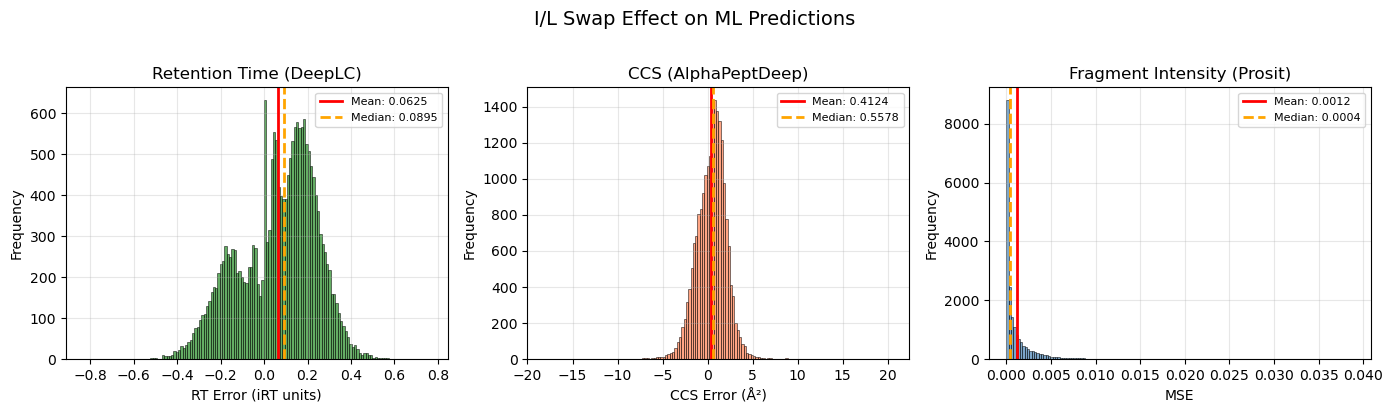

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Fragment Intensity: MSE
ax = axes[2]
values = score_df["mse"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("MSE")
ax.set_ylabel("Frequency")
ax.set_title("Fragment Intensity (Prosit)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# CCS: Error
ax = axes[1]
values = peptides_predictions_ccs["error"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='coral', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("CCS Error (Å²)")
ax.set_ylabel("Frequency")
ax.set_title("CCS (AlphaPeptDeep)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Retention Time: Error
ax = axes[0]
values = peptides_predictions_rt["rt_error"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='forestgreen', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("RT Error (iRT units)")
ax.set_ylabel("Frequency")
ax.set_title("Retention Time (DeepLC)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("I/L Swap Effect on ML Predictions", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../temp_data/simplified_il_swap_figure.png", dpi=300, bbox_inches='tight')
plt.show()